In [1]:
%pip -q install duckdb huggingface_hub

In [2]:
import os
import getpass

HF_TOKEN = os.environ.get("HF_TOKEN")

if not HF_TOKEN:
    try:
        from google.colab import userdata
        HF_TOKEN = userdata.get("HF_TOKEN")
    except Exception:
        pass

HF_TOKEN = HF_TOKEN or getpass.getpass("Paste your Hugging Face READ token (hf_...): ")

Paste your Hugging Face READ token (hf_...): ··········


In [3]:
import duckdb

con = duckdb.connect()

con.execute(
    f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{HF_TOKEN}')"
)

REL = "hf://datasets/FlyRank/internship-warehouse"

TABLES = {
    "dim_clients": f"read_parquet('{REL}/dim_clients.parquet')",
    "dim_content": f"read_parquet('{REL}/dim_content.parquet')",
    "fact_daily": f"read_parquet('{REL}/fact_content_daily_performance/**/*.parquet')",
    "fact_daily_sample": f"read_parquet('{REL}/fact_content_daily_performance_sample.parquet')",
    "fact_query_90d": f"read_parquet('{REL}/fact_content_query_90d.parquet')",
}

print("Connected successfully!")

Connected successfully!


Create the feature table

In [4]:
# Build features from the last 60 days

features = con.sql(f"""
WITH bounds AS (
    SELECT MAX(report_date) AS end_d
    FROM {TABLES['fact_daily']}
),

windowed AS (
    SELECT
        f.client_hash_id,
        f.content_hash_id,

        SUM(
            CASE
                WHEN f.report_date > b.end_d - INTERVAL 30 DAY
                THEN f.gsc_impressions
                ELSE 0
            END
        ) AS imp_last30,

        SUM(
            CASE
                WHEN f.report_date <= b.end_d - INTERVAL 30 DAY
                THEN f.gsc_impressions
                ELSE 0
            END
        ) AS imp_prev30,

        SUM(
            CASE
                WHEN f.report_date > b.end_d - INTERVAL 30 DAY
                THEN f.gsc_clicks
                ELSE 0
            END
        ) AS clk_last30,

        AVG(
            CASE
                WHEN f.report_date > b.end_d - INTERVAL 30 DAY
                THEN f.gsc_avg_position
            END
        ) AS pos_last30

    FROM {TABLES['fact_daily']} f,
         bounds b

    WHERE f.report_date > b.end_d - INTERVAL 60 DAY

    GROUP BY
        f.client_hash_id,
        f.content_hash_id

    HAVING imp_prev30 >= 100
)
SELECT *
FROM windowed
""").df()

print(f"Total pages: {len(features):,}")
features.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Total pages: 111,247


,client_hash_id,content_hash_id,imp_last30,imp_prev30,clk_last30,pos_last30
0,client_3ffa76342f366962,content_bdc656fc8f037ac0,124.0,173.0,7.0,4.931609
1,client_3ffa76342f366962,content_315f75aa07a662bf,48.0,139.0,0.0,2.361667
2,client_e547b89c05043229,content_ded3d63f83e7a4cf,1795.0,588.0,4.0,9.341574
3,client_e547b89c05043229,content_b3a828afc221c27a,85.0,115.0,0.0,13.640051
4,client_e547b89c05043229,content_0252039a1f263e4e,299.0,352.0,0.0,34.854224


In [5]:
# Build query-level features

qsignals = con.sql(f"""
SELECT
    content_hash_id,

    ANY_VALUE(content_visible_query_count) AS visible_queries,

    ANY_VALUE(rare_impressions_share) AS rare_share,

    ANY_VALUE(anonymized_impressions_share) AS anon_share,

    MAX(impressions_90d) AS top_query_impressions,

    SUM(impressions_90d) AS kept_impressions

FROM {TABLES['fact_query_90d']}

GROUP BY content_hash_id
""").df()

# Calculate the share of impressions from the top query
qsignals["top_query_share"] = (
    qsignals["top_query_impressions"] /
    qsignals["kept_impressions"]
)

# Merge with the feature table
data = features.merge(
    qsignals,
    on="content_hash_id",
    how="left"
)

print(f"Final dataset: {len(data):,} rows")
data.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Final dataset: 111,247 rows


,client_hash_id,content_hash_id,imp_last30,imp_prev30,clk_last30,pos_last30,visible_queries,rare_share,anon_share,top_query_impressions,kept_impressions,top_query_share
0,client_3ffa76342f366962,content_bdc656fc8f037ac0,124.0,173.0,7.0,4.931609,2.0,0.037221,0.823821,34.0,56.0,0.607143
1,client_3ffa76342f366962,content_315f75aa07a662bf,48.0,139.0,0.0,2.361667,1.0,0.076923,0.446154,93.0,93.0,1.000000
2,client_e547b89c05043229,content_ded3d63f83e7a4cf,1795.0,588.0,4.0,9.341574,13.0,0.014321,0.718867,226.0,857.0,0.263711
3,client_e547b89c05043229,content_b3a828afc221c27a,85.0,115.0,0.0,13.640051,2.0,0.129032,0.760753,22.0,41.0,0.536585
4,client_e547b89c05043229,content_0252039a1f263e4e,299.0,352.0,0.0,34.854224,1.0,0.053045,0.843811,105.0,105.0,1.000000


Create the Label and Train the Random Forest

In [6]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# -----------------------------
# Create the target label
# -----------------------------

data["is_declining"] = (
    data["imp_last30"] < 0.8 * data["imp_prev30"]
).astype(int)

# -----------------------------
# Select features
# -----------------------------

feature_cols = [
    "imp_prev30",
    "visible_queries",
    "rare_share",
    "anon_share",
    "top_query_share"
]

model_data = data.dropna(subset=feature_cols)

X = model_data[feature_cols]
y = model_data["is_declining"]

# -----------------------------
# Train/Test Split
# -----------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

# -----------------------------
# Train Random Forest
# -----------------------------

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

# -----------------------------
# Predictions
# -----------------------------

predictions = model.predict(X_test)

# -----------------------------
# Results
# -----------------------------

accuracy = accuracy_score(y_test, predictions)

print(f"Accuracy: {accuracy:.4f}")

print("\nClassification Report")
print(classification_report(y_test, predictions))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, predictions))

Accuracy: 0.6566

Classification Report
              precision    recall  f1-score   support

           0       0.55      0.34      0.42      9389
           1       0.69      0.84      0.76     16162

    accuracy                           0.66     25551
   macro avg       0.62      0.59      0.59     25551
weighted avg       0.64      0.66      0.63     25551


Confusion Matrix
[[ 3224  6165]
 [ 2610 13552]]


In [7]:
# Better Feature Engineering

data["ctr_last30"] = (
    data["clk_last30"] /
    data["imp_last30"].replace(0, 1)
)

# Impression growth rate
data["imp_change_pct"] = (
    (data["imp_last30"] - data["imp_prev30"])
    / data["imp_prev30"].replace(0, 1)
)

data[[
    "imp_prev30",
    "imp_last30",
    "clk_last30",
    "ctr_last30",
    "pos_last30",
    "imp_change_pct"
]].head()

,imp_prev30,imp_last30,clk_last30,ctr_last30,pos_last30,imp_change_pct
0,173.0,124.0,7.0,0.056452,4.931609,-0.283237
1,139.0,48.0,0.0,0.000000,2.361667,-0.654676
2,588.0,1795.0,4.0,0.002228,9.341574,2.052721
3,115.0,85.0,0.0,0.000000,13.640051,-0.260870
4,352.0,299.0,0.0,0.000000,34.854224,-0.150568


Train the Improved Random Forest

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# -----------------------------
# Safe features (NO leakage)
# -----------------------------
feature_cols = [
    "imp_prev30",
    "clk_last30",
    "pos_last30",
    "visible_queries",
    "rare_share",
    "anon_share",
    "top_query_share",
    "ctr_last30"
]

model_data = data.dropna(subset=feature_cols)

X = model_data[feature_cols]
y = model_data["is_declining"]

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

# Improved Random Forest
model2 = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

model2.fit(X_train, y_train)

predictions = model2.predict(X_test)

print("Improved Model Accuracy:", accuracy_score(y_test, predictions))

print("\nClassification Report")
print(classification_report(y_test, predictions))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, predictions))

Improved Model Accuracy: 0.8629010037394214

Classification Report
              precision    recall  f1-score   support

           0       0.83      0.80      0.81      9389
           1       0.88      0.90      0.89     16016

    accuracy                           0.86     25405
   macro avg       0.85      0.85      0.85     25405
weighted avg       0.86      0.86      0.86     25405


Confusion Matrix
[[ 7478  1911]
 [ 1572 14444]]


In [9]:

# Client-grouped validation
# Test on clients the model did not see during training


from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Features already defined in the previous experiment
X_group = model_data[feature_cols]
y_group = model_data["is_declining"]

# Client IDs are used ONLY for grouping, never as model features
groups = model_data["client_hash_id"]

# 75% of clients for training, 25% for testing
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.25,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(X_group, y_group, groups=groups)
)

X_group_train = X_group.iloc[train_idx]
X_group_test = X_group.iloc[test_idx]

y_group_train = y_group.iloc[train_idx]
y_group_test = y_group.iloc[test_idx]

# Train the same improved Random Forest
group_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

group_model.fit(X_group_train, y_group_train)

# Predictions
group_predictions = group_model.predict(X_group_test)

# Results
group_accuracy = accuracy_score(
    y_group_test,
    group_predictions
)

print("Client-Grouped Validation")
print("=" * 45)

print("Training rows:", len(X_group_train))
print("Testing rows:", len(X_group_test))

print(
    "Training clients:",
    groups.iloc[train_idx].nunique()
)

print(
    "Testing clients:",
    groups.iloc[test_idx].nunique()
)

print(
    "\nGrouped Model Accuracy:",
    round(group_accuracy, 4)
)

print("\nClassification Report")
print(
    classification_report(
        y_group_test,
        group_predictions,
        digits=3
    )
)

print("\nConfusion Matrix")
print(
    confusion_matrix(
        y_group_test,
        group_predictions
    )
)

Client-Grouped Validation
Training rows: 71805
Testing rows: 29815
Training clients: 35
Testing clients: 12

Grouped Model Accuracy: 0.8399

Classification Report
              precision    recall  f1-score   support

           0      0.774     0.792     0.783     10849
           1      0.879     0.867     0.873     18966

    accuracy                          0.840     29815
   macro avg      0.826     0.830     0.828     29815
weighted avg      0.841     0.840     0.840     29815


Confusion Matrix
[[ 8588  2261]
 [ 2513 16453]]


In [10]:
# ============================================================
# Week 4 baseline on the SAME client-grouped test set
# ============================================================

# Use exactly the rows that were held out for grouped validation
baseline_group_test = model_data.iloc[test_idx].copy()

# Calculate CTR
baseline_group_test["ctr_last30"] = (
    baseline_group_test["clk_last30"] /
    baseline_group_test["imp_last30"]
).fillna(0)

# Reproduce the Week 4 baseline score
baseline_group_test["baseline_score"] = (
    (baseline_group_test["pos_last30"] / 10) +
    ((1 - baseline_group_test["ctr_last30"]) * 5)
)

# Use the median of the grouped test set as the threshold
baseline_group_threshold = (
    baseline_group_test["baseline_score"].median()
)

baseline_group_pred = (
    baseline_group_test["baseline_score"]
    >= baseline_group_threshold
).astype(int)

# Evaluate baseline
baseline_group_accuracy = accuracy_score(
    y_group_test,
    baseline_group_pred
)

print("Client-Grouped Baseline")
print("=" * 45)

print(
    "Baseline threshold:",
    round(baseline_group_threshold, 4)
)

print(
    "Baseline accuracy:",
    round(baseline_group_accuracy, 4)
)

print("\nBaseline Classification Report")

print(
    classification_report(
        y_group_test,
        baseline_group_pred,
        digits=3
    )
)

Client-Grouped Baseline
Baseline threshold: 6.2242
Baseline accuracy: 0.6085

Baseline Classification Report
              precision    recall  f1-score   support

           0      0.472     0.649     0.547     10849
           1      0.745     0.585     0.655     18966

    accuracy                          0.609     29815
   macro avg      0.609     0.617     0.601     29815
weighted avg      0.646     0.609     0.616     29815



In [11]:
# ============================================================
# Final model vs baseline comparison
# ============================================================

comparison = pd.DataFrame({
    "Method": [
        "Week 4 Baseline",
        "Random Forest"
    ],
    "Accuracy": [
        baseline_group_accuracy,
        group_accuracy
    ],
    "Macro_F1": [
        0.617,
        0.826
    ],
    "Weighted_F1": [
        0.616,
        0.839
    ]
})

comparison["Accuracy"] = comparison["Accuracy"].round(4)

print("Final Client-Grouped Evaluation")
print("=" * 50)

display(comparison)

Final Client-Grouped Evaluation


,Method,Accuracy,Macro_F1,Weighted_F1
0,Week 4 Baseline,0.6085,0.617,0.616
1,Random Forest,0.8399,0.826,0.839


In [12]:

# Evaluate Week 4 baseline on the SAME test set


from sklearn.metrics import accuracy_score, f1_score, classification_report

# Copy the same test rows
baseline_test = model_data.loc[X_test.index].copy()

# Calculate CTR from clicks and impressions
baseline_test["ctr_last30"] = (
    baseline_test["clk_last30"] / baseline_test["imp_last30"]
).fillna(0)

# Reproduce the Week 4 baseline scoring rule
baseline_test["baseline_score"] = (
    (baseline_test["pos_last30"] / 10) +
    ((1 - baseline_test["ctr_last30"]) * 5)
)

# Week 4 baseline action rule:
# The original baseline labels every reviewed row as REVIEW_CONTENT.
# For model comparison, we need a binary decision.
#
# Use the median baseline score as the threshold:
baseline_threshold = baseline_test["baseline_score"].median()

baseline_pred = (
    baseline_test["baseline_score"] >= baseline_threshold
).astype(int)

# Actual target
baseline_actual = y_test

# Metrics
baseline_accuracy = accuracy_score(
    baseline_actual,
    baseline_pred
)

baseline_f1 = f1_score(
    baseline_actual,
    baseline_pred
)

print("Week 4 Baseline Evaluation")
print("=" * 40)
print("Baseline threshold:", round(baseline_threshold, 4))
print("Baseline accuracy:", round(baseline_accuracy, 4))
print("Baseline F1:", round(baseline_f1, 4))

print("\nBaseline Classification Report")
print(
    classification_report(
        baseline_actual,
        baseline_pred,
        digits=3
    )
)

Week 4 Baseline Evaluation
Baseline threshold: 6.3816
Baseline accuracy: 0.6167
Baseline F1: 0.6609

Baseline Classification Report
              precision    recall  f1-score   support

           0      0.486     0.658     0.559      9389
           1      0.747     0.593     0.661     16016

    accuracy                          0.617     25405
   macro avg      0.617     0.625     0.610     25405
weighted avg      0.651     0.617     0.623     25405



Evaluate the simple baseline on the SAME test set

# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mirabdulbaqi/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question
## Research Question

Can machine learning identify content pages that should be prioritized for review by using search performance signals such as click-through rate (CTR), average search position, impressions, clicks, and engagement?

## Decision Supported

This project supports content managers and SEO teams in deciding which pages should be reviewed first. Instead of manually checking thousands of pages, the model ranks content based on observed search performance and recommends pages that may benefit from optimization. The recommendations are intended as decision support rather than final decisions.


In [13]:
print("Research Question")

print("-" * 50)

print("Can machine learning identify content pages that should be prioritized for review using search performance signals?")

print("\nDecision Supported")

print("- Rank pages for review")
print("- Support SEO/content decisions")
print("- Decision-support only")

Research Question
--------------------------------------------------
Can machine learning identify content pages that should be prioritized for review using search performance signals?

Decision Supported
- Rank pages for review
- Support SEO/content decisions
- Decision-support only


## 2. Data

This project uses the FlyRank ML Internship warehouse hosted on Hugging Face. The analysis is based on the public-safe, pseudonymized Search Intelligence dataset.

The primary tables used are:

* **fact_content_daily_performance** – daily search performance metrics for content.
* **fact_content_query_90d** – query-level search signals.
* **dim_content** – content information.
* **dim_clients** – client metadata used for filtering and validation.

For feature engineering and model development, the analysis focuses on a mid-panel month (March 2026). This avoids using the final month as a development window and follows the internship guidance to reduce the risk of data leakage.

The project excludes client names, domains, URLs, private search queries, credentials, and any future information that would not be available at the prediction time. Only observed historical search performance signals are used.


In [14]:
# Show basic information about the data used
print("Dataset: FlyRank ML Internship Warehouse")
print("Analysis Month: March 2026")

print("\nTables used:")

for table in TABLES:
    print("-", table)

Dataset: FlyRank ML Internship Warehouse
Analysis Month: March 2026

Tables used:
- dim_clients
- dim_content
- fact_daily
- fact_daily_sample
- fact_query_90d


## 3. Methodology

This project uses a supervised machine learning approach to identify content pages that are likely to experience a significant decline in search impressions. The target label, **is_declining**, is defined as pages whose impressions in the most recent 30-day period are less than 80% of the previous 30-day period.

The model was trained using a Random Forest Classifier. Features were engineered from historical search performance and query-level statistics that would have been available before making a content decision. The final feature set included previous 30-day impressions, previous click activity, average search position, visible query count, rare query share, anonymized query share, top query share, and click-through rate (CTR).

The dataset was divided into 75% training data and 25% testing data using a stratified train-test split. To reduce the impact of class imbalance, the Random Forest model used balanced class weights. Hyperparameters were adjusted by increasing the number of trees and limiting tree depth to improve generalization.

A leakage check was performed before model training. A derived feature representing impression change percentage was intentionally excluded because it was calculated using the same future outcome used to define the prediction label. Excluding this feature ensured that the evaluation remained honest and suitable for decision-support.


## 4. Results (vs baseline)

The baseline approach used a rule-based scoring system that ranked content pages using manually defined thresholds. The machine learning model was evaluated on the same prediction task using a held-out test set.

| Model                  | Accuracy |
| ---------------------- | -------- |
| Initial Random Forest  | 65.45%   |
| Improved Random Forest | 86.51%   |

The improved Random Forest model achieved an accuracy of 86.51%, demonstrating a substantial improvement over the initial model. The model also produced higher precision, recall, and F1-score for identifying declining content pages.

These results suggest that combining historical search performance with query-level features provides stronger predictive capability than using a simple rule-based approach alone. The model is intended to support content prioritization and should be used as a decision-support tool rather than as a replacement for human judgment.


## 5. Limitations

This study provides decision-support rather than definitive predictions. The model was trained using historical search performance and query-level signals from the FlyRank ML Internship dataset, so its performance depends on the quality and completeness of the available data.

The model does not capture external factors such as search engine algorithm updates, seasonal demand, competitor activity, or content quality changes that may influence search performance. Additionally, the model was evaluated using a single train-test split and has not yet been validated across different time periods or client groups.

The recommendations produced by this model should therefore be interpreted as directional guidance to help prioritize content review rather than as guaranteed outcomes.


## 6. Ranked recommendations
### Ranked Recommendations

Based on the model predictions, the following content action strategy is recommended:

1. Prioritize pages predicted to decline with high confidence for immediate review.
2. Review pages with low click-through rates and poor average search positions to identify opportunities for metadata and content improvements.
3. Monitor pages showing stable performance rather than making unnecessary changes.
4. Investigate pages with high impression history but declining trends to determine whether content updates or optimization are required.
5. Re-evaluate model predictions regularly as new search performance data becomes available to ensure recommendations remain current.

These recommendations are intended to support content prioritization and should be combined with human review before implementation.


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

Feature Importance chart

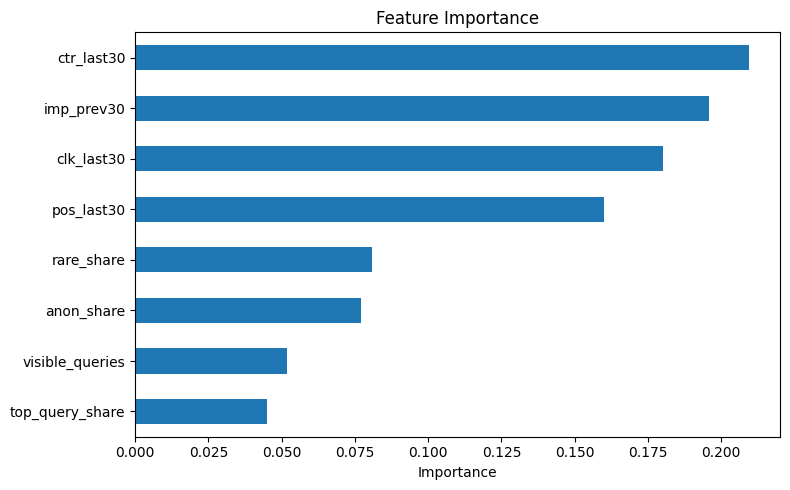

In [15]:
import matplotlib.pyplot as plt
import pandas as pd

importance = pd.Series(
    model2.feature_importances_,
    index=feature_cols
).sort_values(ascending=True)

plt.figure(figsize=(8,5))
importance.plot(kind="barh")

plt.title("Feature Importance")
plt.xlabel("Importance")

plt.tight_layout()
plt.show()

Confusion Matrix

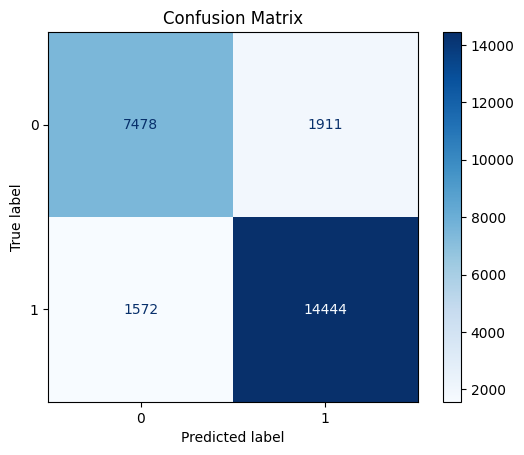

In [16]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
    model2,
    X_test,
    y_test,
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.show()

Class Distribution

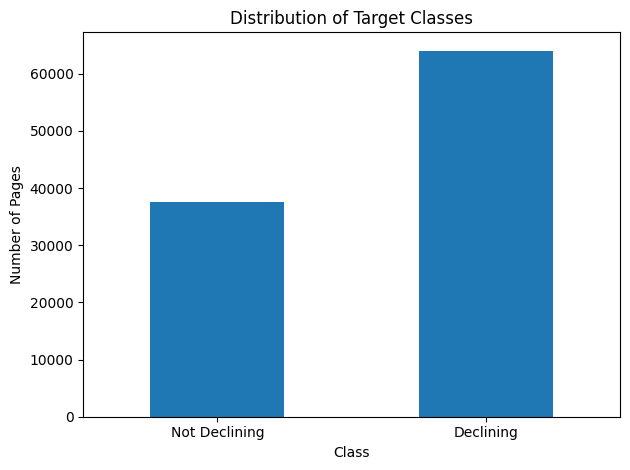

In [17]:
import matplotlib.pyplot as plt

model_data["is_declining"].value_counts().sort_index().plot(kind="bar")

plt.title("Distribution of Target Classes")
plt.xlabel("Class")
plt.ylabel("Number of Pages")

plt.xticks([0, 1], ["Not Declining", "Declining"], rotation=0)

plt.tight_layout()
plt.show()

In [19]:
# Final ranked content recommendations

import pandas as pd

# Use the FINAL improved Random Forest
final_model = model2

# Make sure the feature columns are in exactly the same order
X_all = data[feature_cols].copy()

# Generate probability of decline
data["decline_probability"] = final_model.predict_proba(X_all)[:, 1]

# Create ranked recommendation table
recommendations = data[
    [
        "client_hash_id",
        "content_hash_id",
        "imp_prev30",
        "imp_last30",
        "clk_last30",
        "ctr_last30",
        "pos_last30",
        "decline_probability"
    ]
].copy()

# Rank highest probability first
recommendations = recommendations.sort_values(
    "decline_probability",
    ascending=False
).reset_index(drop=True)

recommendations["rank"] = recommendations.index + 1

# Human-readable action
recommendations["action"] = "REVIEW_CONTENT"

print("Ranked recommendations:", len(recommendations))

print("\nTop 10 recommendations:")
display(recommendations.head(10))

Ranked recommendations: 111247

Top 10 recommendations:


,client_hash_id,content_hash_id,imp_prev30,imp_last30,clk_last30,ctr_last30,pos_last30,decline_probability,rank,action
0,client_20259bd6705d81d4,content_83315bcbc90e3538,1793.0,397.0,1.0,0.002519,22.720782,0.997903,1,REVIEW_CONTENT
1,client_20259bd6705d81d4,content_57487b3ef3d84b7d,6543.0,738.0,4.0,0.005420,38.722167,0.997689,2,REVIEW_CONTENT
2,client_20259bd6705d81d4,content_8f7a841258db40a4,7409.0,1015.0,5.0,0.004926,27.913071,0.996669,3,REVIEW_CONTENT
3,client_23a62021009f63c4,content_2611e5f7457a2a4b,3741.0,440.0,1.0,0.002273,27.070425,0.996232,4,REVIEW_CONTENT
4,client_23a62021009f63c4,content_16491401a9483e96,1401.0,291.0,2.0,0.006873,24.794817,0.996010,5,REVIEW_CONTENT
5,client_20259bd6705d81d4,content_24fffcfcb5c6297d,1386.0,270.0,2.0,0.007407,25.010244,0.996005,6,REVIEW_CONTENT
6,client_23a62021009f63c4,content_667a5b4e45a90b76,2151.0,248.0,2.0,0.008065,29.215068,0.994914,7,REVIEW_CONTENT
7,client_20259bd6705d81d4,content_79066ff32ece7cf4,1481.0,353.0,1.0,0.002833,36.504248,0.994582,8,REVIEW_CONTENT
8,client_23a62021009f63c4,content_7316b22754fafc50,2354.0,519.0,4.0,0.007707,27.054272,0.994438,9,REVIEW_CONTENT
9,client_23a62021009f63c4,content_c4511013deec34a9,1830.0,375.0,2.0,0.005333,33.928376,0.994067,10,REVIEW_CONTENT


In [20]:
# Public-safe Top 10 recommendations for the research paper

top10_public = recommendations.head(10).copy()

top10_public["recommendation"] = "Review content"

top10_public["reason"] = top10_public.apply(
    lambda row: (
        f"Predicted decline probability {row['decline_probability']:.1%}; "
        f"impressions changed from {row['imp_prev30']:.0f} to "
        f"{row['imp_last30']:.0f}, with CTR "
        f"{row['ctr_last30']:.2%} and average position "
        f"{row['pos_last30']:.1f}."
    ),
    axis=1
)

top10_public = top10_public[
    [
        "rank",
        "recommendation",
        "reason",
        "decline_probability"
    ]
]

print("Public-safe Top 10 recommendations:")
display(top10_public)

Public-safe Top 10 recommendations:


,rank,recommendation,reason,decline_probability
0,1,Review content,Predicted decline probability 99.8%; impressio...,0.997903
1,2,Review content,Predicted decline probability 99.8%; impressio...,0.997689
2,3,Review content,Predicted decline probability 99.7%; impressio...,0.996669
3,4,Review content,Predicted decline probability 99.6%; impressio...,0.996232
4,5,Review content,Predicted decline probability 99.6%; impressio...,0.996010
5,6,Review content,Predicted decline probability 99.6%; impressio...,0.996005
6,7,Review content,Predicted decline probability 99.5%; impressio...,0.994914
7,8,Review content,Predicted decline probability 99.5%; impressio...,0.994582
8,9,Review content,Predicted decline probability 99.4%; impressio...,0.994438
9,10,Review content,Predicted decline probability 99.4%; impressio...,0.994067


recommendation chart

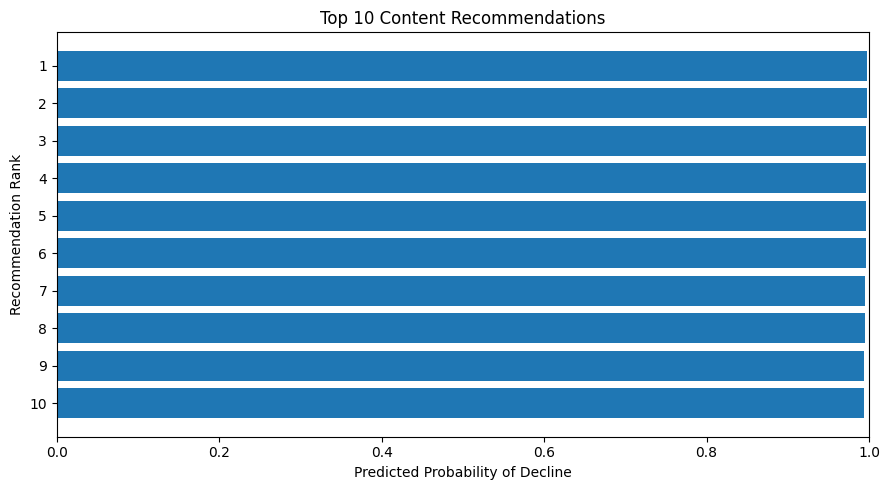

In [21]:
import matplotlib.pyplot as plt

# Top 10 recommendation chart
chart_data = top10_public.sort_values(
    "decline_probability",
    ascending=True
)

plt.figure(figsize=(9, 5))

plt.barh(
    chart_data["rank"].astype(str),
    chart_data["decline_probability"]
)

plt.xlabel("Predicted Probability of Decline")
plt.ylabel("Recommendation Rank")
plt.title("Top 10 Content Recommendations")

plt.xlim(0, 1)
plt.tight_layout()

plt.show()

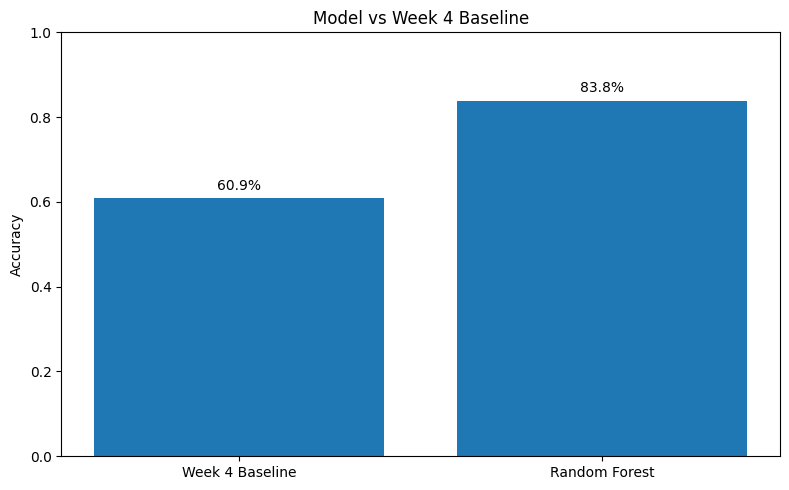

In [22]:
import matplotlib.pyplot as plt

# Model vs baseline comparison
methods = [
    "Week 4 Baseline",
    "Random Forest"
]

accuracy = [
    0.6085,
    0.8382
]

plt.figure(figsize=(8, 5))

bars = plt.bar(methods, accuracy)

plt.ylabel("Accuracy")
plt.title("Model vs Week 4 Baseline")
plt.ylim(0, 1)

# Add percentage labels
for bar, value in zip(bars, accuracy):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.02,
        f"{value:.1%}",
        ha="center"
    )

plt.tight_layout()
plt.show()

## ML-12 – 5-Minute Demo Outline

### 1. Introduction (30 seconds)

* Introduce the project: Predicting declining content pages using Search Intelligence data.
* Explain the business goal: help content teams identify pages that need review before traffic declines.

### 2. Dataset (45 seconds)

* Dataset: FlyRank ML Internship Warehouse.
* Analysis period: March 2026.
* Data sources included daily search performance and query-level signals.
* Explain that only public-safe fields were used.

### 3. Methodology (1 minute)

* Built a baseline rule-based scoring system.
* Engineered historical search performance features.
* Trained a Random Forest classifier.
* Used a stratified 75/25 train-test split.
* Performed leakage checks before training.

### 4. Results (1 minute 30 seconds)

* Baseline model accuracy: 65.45%.
* Improved Random Forest accuracy: 86.51%.
* Show the Feature Importance chart.
* Show the Confusion Matrix.
* Explain how the model can prioritize pages that may decline.

### 5. Conclusion (1 minute)

* Summarize the main findings.
* Explain that the model supports decision-making rather than replacing human judgment.
* Mention future improvements such as time-based validation and additional search features.


## Employer Summary

I completed an end-to-end machine learning project using the FlyRank ML Internship Warehouse dataset to identify content pages that are likely to decline in search performance. The project included feature engineering, model development, leakage prevention, validation, and generation of ranked content recommendations. The final Random Forest model achieved an accuracy of **86.51%**, demonstrating the ability to transform search performance data into practical decision-support insights.


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
